In [ ]:
"""
Author    : Mohammad Norizadeh Cherloo
Project   : MNIST Digit Classification
Algorithm : GoogleNet original version (2014) – PyTorch
"""

import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.datasets import load_digits
from torch.nn import functional as F
import torchvision
from torchvision.transforms import ToTensor, Lambda
from torch import nn, optim

In [72]:
from torch.utils.data import DataLoader, random_split

# %% MNIST dataset
num_classes = 10
batch_size = 32

# target_transform = Lambda(
#     lambda y: torch.zeros(num_classes).scatter_(0, torch.tensor(y), 1)
# )

full_train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=ToTensor(),
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=ToTensor(),
)


In [73]:
train_size = 50000
val_size   = 10000

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)


In [74]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [ ]:
class LightGoogleNet(nn.Module):
    def __init__(self,num_classes= 10):
        super(LightGoogleNet, self).__init__()
        # ******************* stem ********************#
        self.stem= nn.Sequential(nn.LazyConv2d(out_channels=16,kernel_size=5,padding=2),
                                #  nn.LazyBatchNorm2d(momentum=0.1),
                                 nn.ReLU(),
                                 nn.MaxPool2d(kernel_size=2,stride=2), 
                                 nn.LazyConv2d(out_channels=32,kernel_size=1),
                                 #  nn.LazyBatchNorm2d(momentum=0.1),
                                 nn.ReLU()
                                 )
        # ******************* block1 ********************#
        self.block1= nn.Sequential(Inception(c1=8,c2=(8,16),c3=(4,8),c4=8),
                                   Inception(c1=16,c2=(16,24),c3=(8,16),c4=8),
                                   nn.MaxPool2d(kernel_size=2,stride=2))               
        
        # ******************* block2 ********************#                          
        self.block2_1= Inception(c1=16,c2=(16,32),c3=(8,16),c4=16)
        self.aux1= AuxiliaryClassifier(num_classes=num_classes)
        
        self.block2_2= Inception(c1=24,c2=(24,32),c3=(8,16),c4=16)
        self.aux2= AuxiliaryClassifier(num_classes=num_classes)
        
        # ******************* block3 ********************#
        self.block3= Inception(c1=32,c2=(32,48),c3=(8,16),c4=16)
        # ******************* head ********************#
        self.head= nn.Sequential(nn.AdaptiveAvgPool2d((3,3)),
                                 nn.Flatten(),
                                #  nn.Dropout(0.4),
                                 nn.LazyLinear(num_classes))
    def forward(self,x):
       # X: bs x 1 x H x W
       out= self.stem(x)
       out= self.block1(out)
       
       out= self.block2_1(out)
       out1= self.aux1(out)
       
       out= self.block2_2(out)
       out2= self.aux2(out)
       
       out= self.block3(out)
       out= self.head(out)
       return out,out1,out2

class Inception(nn.Module):
    def __init__(self, c1=8, c2=(8,16),c3=(8,16),c4=16 ):
        super(Inception, self).__init__()
        self.b1= nn.Sequential(nn.LazyConv2d(out_channels=c1,kernel_size=1),
                                #  nn.LazyBatchNorm2d(momentum=0.1),
                                 nn.ReLU())
        self.b2= nn.Sequential(nn.LazyConv2d(out_channels=c2[0],kernel_size=1),
                            #    nn.LazyBatchNorm2d(momentum=0.1),
                               nn.ReLU(),
                                 
                                nn.LazyConv2d(out_channels=c2[1],kernel_size=3,padding=1),
                                # nn.LazyBatchNorm2d(momentum=0.1),
                                nn.ReLU()) 
        
        self.b3= nn.Sequential(nn.LazyConv2d(out_channels=c3[0],kernel_size=1),
                                #  nn.LazyBatchNorm2d(momentum=0.1),
                                 nn.ReLU(),
                                 
                                 nn.LazyConv2d(out_channels=c3[1],kernel_size=5,padding=2),
                                #  nn.LazyBatchNorm2d(momentum=0.1),
                                 nn.ReLU()) 
        
        self.b4= nn.Sequential(nn.MaxPool2d(kernel_size=3,stride=1,padding=1),
                                 nn.LazyConv2d(out_channels=c4,kernel_size=1),
                                #  nn.LazyBatchNorm2d(momentum=0.1),
                                 nn.ReLU()) 
    def forward(self,x):
        b1= self.b1(x)
        b2= self.b2(x)
        b3= self.b3(x)
        b4= self.b4(x)
        out= torch.cat((b1,b2,b3,b4),dim=1)
        return out 


class AuxiliaryClassifier(nn.Module):
    def __init__(self,num_classes=10):
        super(AuxiliaryClassifier, self).__init__()
        self.net= nn.Sequential(nn.AdaptiveMaxPool2d((4,4)),
                               nn.LazyConv2d(out_channels=32,kernel_size=1),
                               nn.ReLU(),
                               nn.Flatten(),
                               nn.LazyLinear(out_features=64),
                               nn.ReLU(),
                            #    nn.Dropout(0.4),
                               nn.LazyLinear(out_features=num_classes)
                               )

    def forward(self,x):
        out= self.net(x)
        return out 

In [ ]:
model= LightGoogleNet(num_classes= 10)
n_out=10

criterion= nn.CrossEntropyLoss()

optimizer= optim.SGD(params=model.parameters(),
                      lr=0.01, momentum=0.9)
alpha= 0.3

In [77]:
# give input to the model to initialize the lazy layers
y=model(torch.randn(2,1,28,28))
# show the model architecture
# print(model)
def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        nn.init.zeros_(m.bias)

model.apply(init_weights)


LightGoogleNet(
  (stem): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1))
    (5): ReLU()
  )
  (block1): Sequential(
    (0): Inception(
      (b1): Sequential(
        (0): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
      )
      (b2): Sequential(
        (0): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
      )
      (b3): Sequential(
        (0): Conv2d(32, 4, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(4, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
        (3): ReLU()
      )
      (b4): Sequential(
        (0): Ma

In [ ]:
mse=[]
epoch=5
for iter in range(epoch):
     er=[]
     for i,(xbatch,ybatch) in enumerate(train_loader):
          model.train()
          # farward pass
          ypred,out1,out2= model(xbatch)
          optimizer.zero_grad()
          loss_main= criterion(ypred,ybatch.long())
          loss_aux1= criterion(out1,ybatch.long())
          loss_aux2= criterion(out2,ybatch.long())
          
          loss= loss_main + alpha*(loss_aux1+loss_aux2)
          loss.backward()
          optimizer.step()

          er.append(loss.detach()) 
          if i%5==0:
               model.eval()
               loss= torch.mean(torch.tensor(er))
               mse.append(loss)
               # validation
               with torch.no_grad():
                    y_pred=[]
                    y_true=[]
                    for j,(xbatch,ybatch) in enumerate(val_loader):
                         # farward pass
                         ypred= model(xbatch)[0]
                         ypred= torch.argmax(ypred,dim=1)
                         y_pred.extend(ypred.numpy())
                         y_true.extend(ybatch.numpy())
                         
                    y_pred= np.array(y_pred)
                    y_true= np.array(y_true)
                    accuracy= np.sum(y_true==y_pred)/y_pred.shape[0]*100
                    print(f'MSE({iter}:{i}): {loss:.6f} **** Acc:{accuracy:.3f}%')
               model.train()
mse=torch.tensor(mse)

plt.subplot(2,1,1)
plt.plot(mse)
plt.show()

MSE(0:0): 4.746459 **** Acc:10.110%
MSE(0:5): 4.032979 **** Acc:14.010%
MSE(0:10): 3.881111 **** Acc:14.730%
MSE(0:15): 3.802025 **** Acc:23.370%
MSE(0:20): 3.759752 **** Acc:13.360%
MSE(0:25): 3.725553 **** Acc:23.940%
MSE(0:30): 3.692386 **** Acc:23.330%
MSE(0:35): 3.658613 **** Acc:27.630%
MSE(0:40): 3.615384 **** Acc:34.430%
MSE(0:45): 3.544420 **** Acc:38.230%
MSE(0:50): 3.496275 **** Acc:58.750%
MSE(0:55): 3.434250 **** Acc:50.960%
MSE(0:60): 3.358801 **** Acc:69.160%
MSE(0:65): 3.249078 **** Acc:66.000%
MSE(0:70): 3.143819 **** Acc:74.220%
MSE(0:75): 3.063807 **** Acc:70.300%
MSE(0:80): 2.959310 **** Acc:81.850%
MSE(0:85): 2.842857 **** Acc:85.020%
MSE(0:90): 2.729657 **** Acc:84.740%
MSE(0:95): 2.634087 **** Acc:80.530%
MSE(0:100): 2.553142 **** Acc:86.430%
MSE(0:105): 2.469945 **** Acc:80.740%
MSE(0:110): 2.397738 **** Acc:90.580%
MSE(0:115): 2.321809 **** Acc:91.250%
MSE(0:120): 2.245220 **** Acc:89.760%
MSE(0:125): 2.180421 **** Acc:91.640%
MSE(0:130): 2.117135 **** Acc:87.4

KeyboardInterrupt: 

Total accuracy:97.530%
accuracy0:98.673%
accuracy1:99.912%
accuracy2:96.899%
accuracy3:91.683%
accuracy4:98.982%
accuracy5:96.525%
accuracy6:98.852%
accuracy7:96.984%
accuracy8:99.076%
accuracy9:97.522%


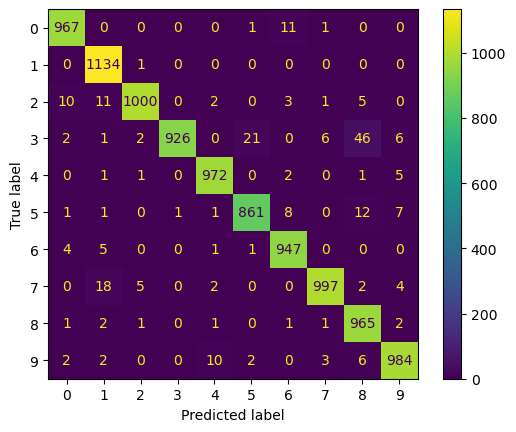

In [79]:
# validation
y_pred=[]
y_true=[]
model.eval()
with torch.no_grad():
    for i,(xbatch,ybatch) in enumerate(test_loader):
        # farward pass
        ypred= model(xbatch)[0]
        ypred= torch.argmax(ypred,dim=1)
        y_pred.extend(ypred.numpy())
        y_true.extend(ybatch.numpy())
        
    y_pred= np.array(y_pred)
    y_true= np.array(y_true)

    from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
    #%% test trained Neural Network
    C= confusion_matrix(y_true,y_pred)
    # print(C)
    accuracy= np.sum(np.diag(C))/ np.sum(C) *100
    print(f'Total accuracy:{accuracy:.3f}%')

for i in range(n_out):
    accuracyi= C[i,i]/ np.sum(C[i,:]) *100
    print(f'accuracy{i}:{accuracyi:.3f}%')
# plt.figure()
disp= ConfusionMatrixDisplay(C)
disp.plot()
plt.show()